# View SWED Dataset

SWED: https://openmldata.ukho.gov.uk/

The notebook associates images and labels of the training set, extracts the first three bands as RGB and shows image, mask and overlay.

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [30]:
# Dataset paths
DATASET_ROOT = Path("Sentinel-2WaterDataset(SWED)") / "SWED"
# Image path
IMAGES_DIR = DATASET_ROOT / "train" / "images"
# Label path
LABELS_DIR = DATASET_ROOT / "train" / "labels"

NUM_SAMPLES = 5       # number of samples to visualize
RANDOM_SAMPLES = False # False: visualize the first NUM_SAMPLES samples, True: visualize NUM_SAMPLES random samples
SEED = 42 # random seed for reproducibility
OVERLAY_ALPHA = 0.45 # transparency of the label overlay on the image

# Check if the dataset folders exist
assert IMAGES_DIR.is_dir(), f"Folder not found: {IMAGES_DIR.resolve()}"
assert LABELS_DIR.is_dir(), f"Folder not found: {LABELS_DIR.resolve()}"

In [31]:
def label_name_from_image(image_name: str) -> str:
    """Converts ..._image_r_c.npy to the corresponding ..._chip_r_c.npy."""
    return image_name.replace("_image_", "_chip_")

# Load image and label path pairs
image_paths = sorted(IMAGES_DIR.glob("*.npy"))
pairs = [
    (image_path, LABELS_DIR / label_name_from_image(image_path.name))
    for image_path in image_paths
]
pairs = [(image_path, label_path) for image_path, label_path in pairs if label_path.exists()]

if not pairs:
    raise RuntimeError("Non è stata trovata alcuna coppia immagine-label.")

# Select samples
if RANDOM_SAMPLES:
    rng = np.random.default_rng(SEED)
    indices = rng.choice(len(pairs), size=min(NUM_SAMPLES, len(pairs)), replace=False)
    selected_pairs = [pairs[index] for index in indices]
else:
    selected_pairs = pairs[:NUM_SAMPLES]

print(f"Images: {len(image_paths):,}")
print(f"Valid image-label pairs: {len(pairs):,}")
print(f"Selected samples: {len(selected_pairs)}")

Images: 28,224
Valid image-label pairs: 28,224
Selected samples: 5


In [40]:
def to_display_rgb(image: np.ndarray) -> np.ndarray:
    """Extracts the first three bands and applies a robust stretch for visualization."""
    if image.ndim != 3:
        raise ValueError(f"Unexpected image shape: {image.shape}")

    # SWED uses (height, width, bands); also supports (bands, height, width).
    rgb = image[..., :3] if image.shape[-1] >= 3 else np.moveaxis(image[:3], 0, -1)
    rgb = rgb.astype(np.float32)

    # The 2°-98° percentile stretch makes Sentinel-2 reflectance values readable.
    low, high = np.percentile(rgb, (2, 98), axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / np.maximum(high - low, 1e-6), 0, 1)


def to_2d_label(label: np.ndarray) -> np.ndarray:
    """Converts a label array to 2D by squeezing singleton dimensions."""
    label = np.squeeze(label)
    if label.ndim != 2:
        raise ValueError(f"Unexpected label shape after squeeze: {label.shape}")
    return label


def show_sample(image_path: Path, label_path: Path, alpha: float = 0.45) -> None:
    """Displays an RGB image, its label, and an overlay of the label on the image."""
    image = np.load(image_path)
    label = to_2d_label(np.load(label_path))
    rgb = to_display_rgb(image)

    if rgb.shape[:2] != label.shape:
        raise ValueError(f"Dimensioni non compatibili: RGB {rgb.shape[:2]}, label {label.shape}")

    classes = np.unique(label)
    # Colors: class with the lowest value = land (beige), class with the highest value = water (blue).
    class_index = np.searchsorted(classes, label)
    colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(classes)))
    if len(classes) > 1:
        colors[0] = (0.76, 0.64, 0.42, 1.0)
    label_cmap = ListedColormap(colors)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    axes[0].imshow(rgb)
    axes[0].set_title("RGB Image (bands 1, 2, 3)")

    axes[1].imshow(class_index, cmap=label_cmap, vmin=0, vmax=max(len(classes) - 1, 1))
    axes[1].set_title(f"Label - values: {classes.tolist()}")

    axes[2].imshow(rgb)
    axes[2].imshow(
        class_index, cmap=label_cmap, vmin=0, vmax=max(len(classes) - 1, 1), alpha=alpha
    )
    axes[2].set_title(f"RGB + label (alpha={alpha})")

    legend = [Patch(facecolor=colors[i], label=f"Class {value}") for i, value in enumerate(classes)]
    axes[2].legend(handles=legend, loc="lower right")
    for axis in axes:
        axis.axis("off")

    fig.suptitle(image_path.stem, fontsize=10)
    plt.show()

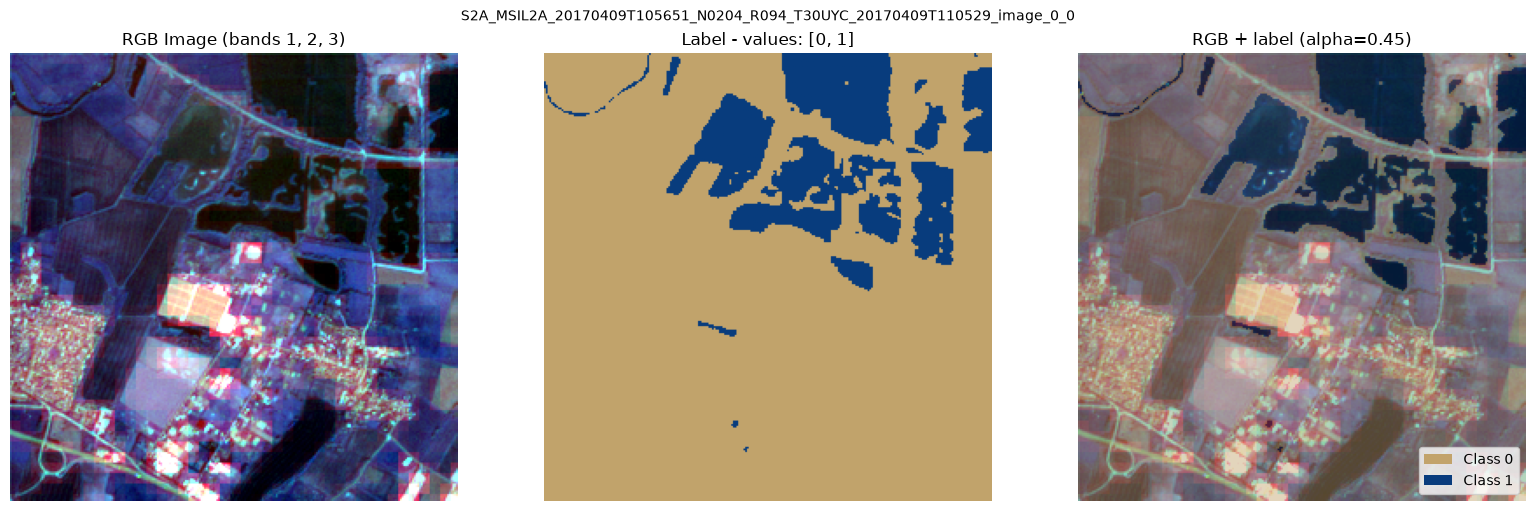

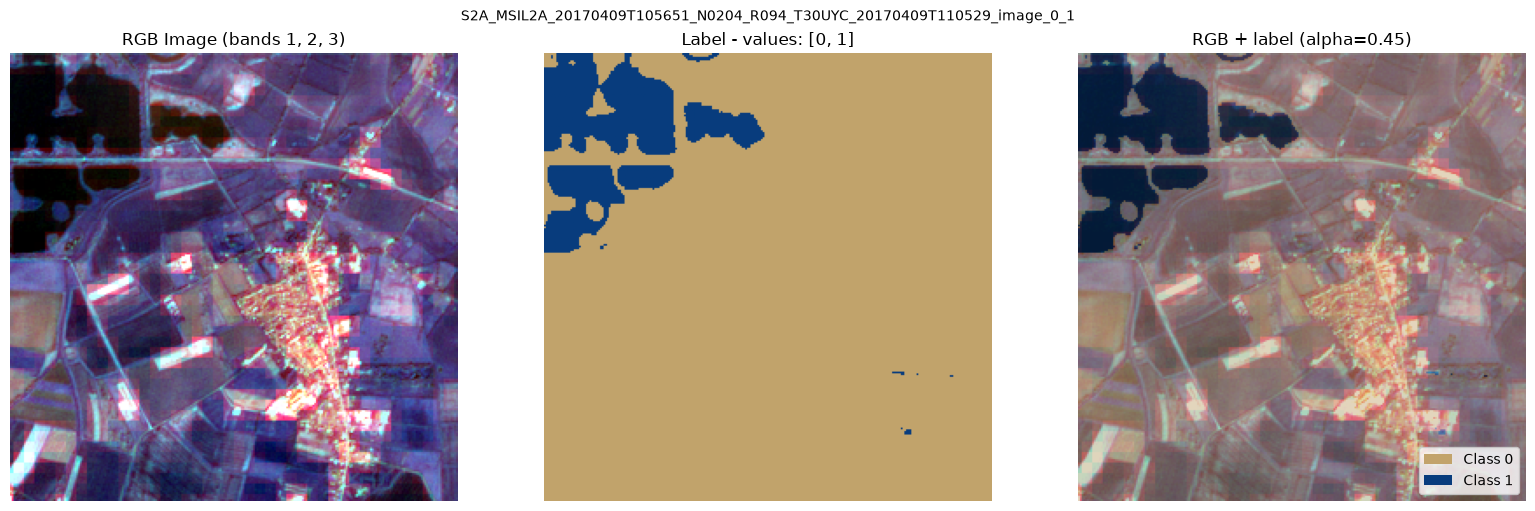

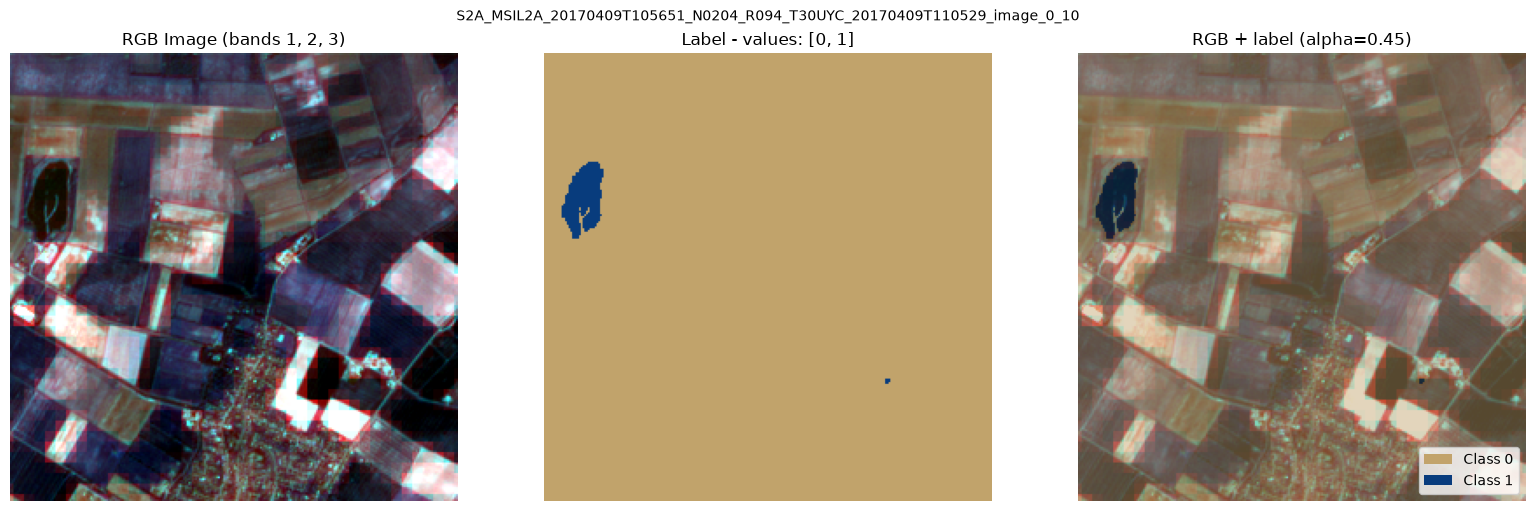

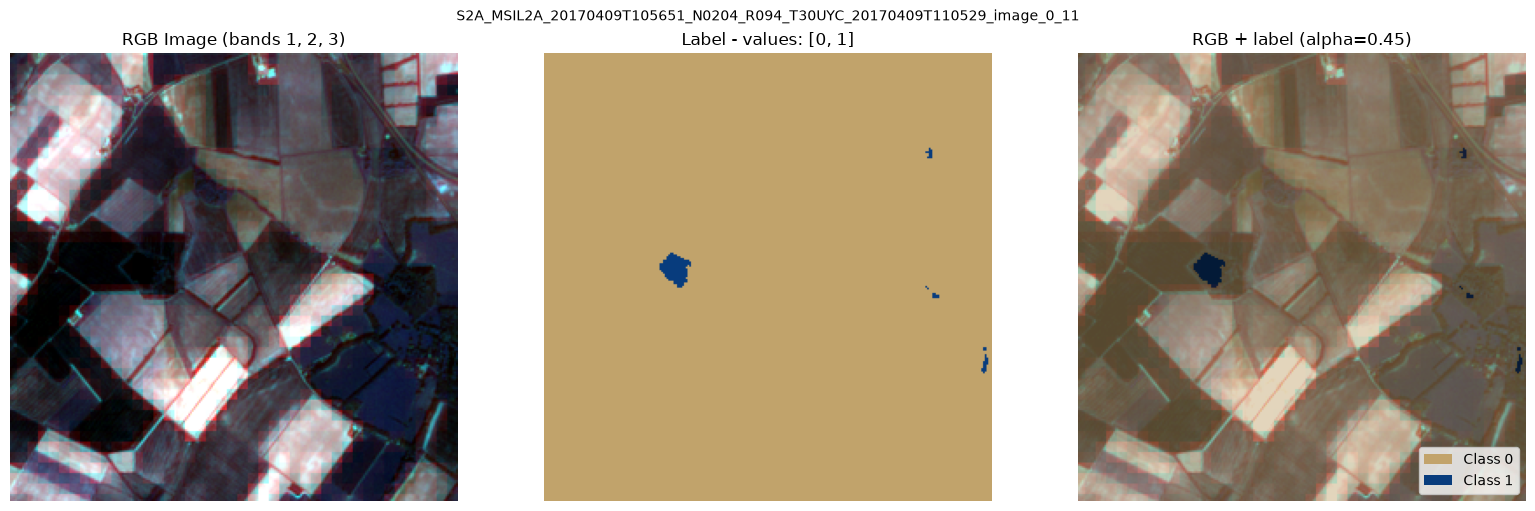

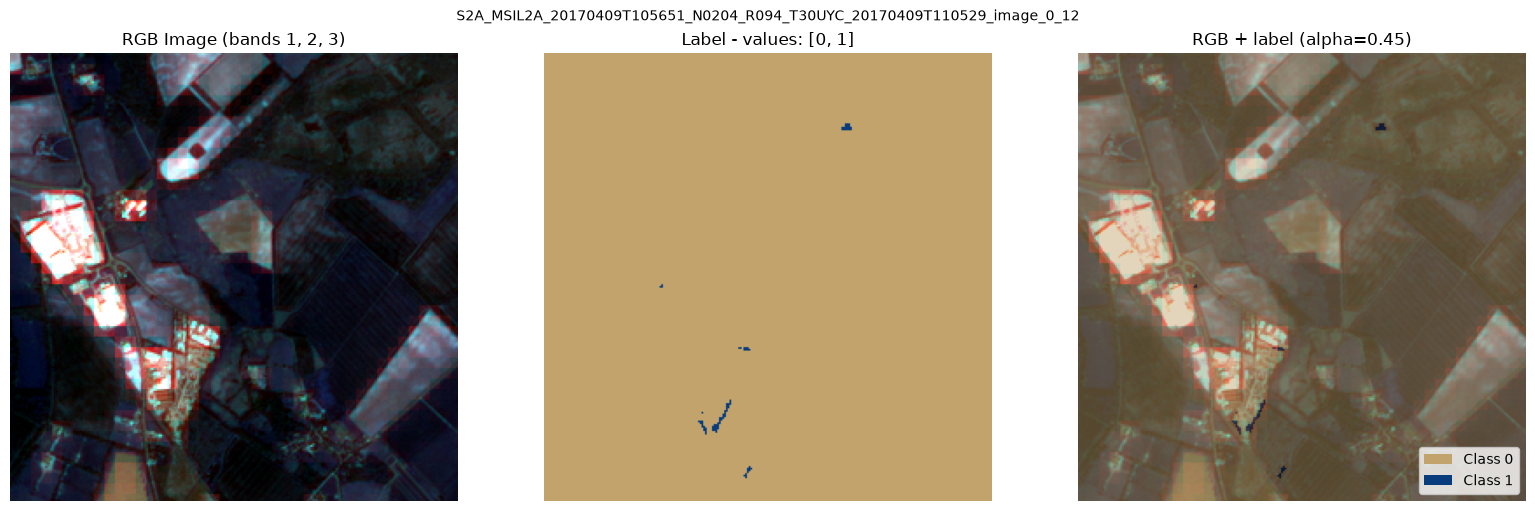

In [41]:
for image_path, label_path in selected_pairs:
    show_sample(image_path, label_path, alpha=OVERLAY_ALPHA)